<a href="https://colab.research.google.com/github/AkankshaB123/ML/blob/main/KNN_document_retrieval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Document retrieval from wikipedia data

## Fire up GraphLab Create

# Load some text data - from wikipedia, pages on people

In [ ]:
people = graphlab.SFrame('people_wiki.gl/')

Data contains:  link to wikipedia article, name of person, text of article.

In [ ]:
people.head()

URI,name,text
<http://dbpedia.org/resource/Digby_Morrell> ...,Digby Morrell,digby morrell born 10october 1979 is a former ...
<http://dbpedia.org/resource/Alfred_J._Lewy> ...,Alfred J. Lewy,alfred j lewy aka sandylewy graduated from ...
<http://dbpedia.org/resource/Harpdog_Brown> ...,Harpdog Brown,harpdog brown is a singerand harmonica player who ...
<http://dbpedia.org/resource/Franz_Rottensteiner> ...,Franz Rottensteiner,franz rottensteiner bornin waidmannsfeld lower ...
<http://dbpedia.org/resource/G-Enka> ...,G-Enka,henry krvits born 30december 1974 in tallinn ...
<http://dbpedia.org/resource/Sam_Henderson> ...,Sam Henderson,sam henderson bornoctober 18 1969 is an ...
<http://dbpedia.org/resource/Aaron_LaCrate> ...,Aaron LaCrate,aaron lacrate is anamerican music producer ...
<http://dbpedia.org/resource/Trevor_Ferguson> ...,Trevor Ferguson,trevor ferguson aka johnfarrow born 11 november ...
<http://dbpedia.org/resource/Grant_Nelson> ...,Grant Nelson,grant nelson born 27april 1971 in london ...
<http://dbpedia.org/resource/Cathy_Caruth> ...,Cathy Caruth,cathy caruth born 1955 isfrank h t rhodes ...


In [ ]:
len(people)

59071

# Explore the dataset and checkout the text it contains

## Exploring the entry for president Obama

In [ ]:
obama = people[people['name'] == 'Barack Obama']

In [ ]:
obama

URI,name,text
<http://dbpedia.org/resource/Barack_Obama> ...,Barack Obama,barack hussein obama iibrk husen bm born august ...


In [ ]:
obama['text']

dtype: str
Rows: ?
['barack hussein obama ii brk husen bm born august 4 1961 is the 44th and current president of the united states and the first african american to hold the office born in honolulu hawaii obama is a graduate of columbia university and harvard law school where he served as president of the harvard law review he was a community organizer in chicago before earning his law degree he worked as a civil rights attorney and taught constitutional law at the university of chicago law school from 1992 to 2004 he served three terms representing the 13th district in the illinois senate from 1997 to 2004 running unsuccessfully for the united states house of representatives in 2000in 2004 obama received national attention during his campaign to represent illinois in the united states senate with his victory in the march democratic party primary his keynote address at the democratic national convention in july and his election to the senate in november he began his presidential campa

## Exploring the entry for actor George Clooney

In [ ]:
clooney = people[people['name'] == 'George Clooney']
clooney['text']

dtype: str
Rows: ?
['george timothy clooney born may 6 1961 is an american actor writer producer director and activist he has received three golden globe awards for his work as an actor and two academy awards one for acting and the other for producingclooney made his acting debut on television in 1978 and later gained wide recognition in his role as dr doug ross on the longrunning medical drama er from 1994 to 1999 for which he received two emmy award nominations while working on er he began attracting a variety of leading roles in films including the superhero film batman robin 1997 and the crime comedy out of sight 1998 in which he first worked with a director who would become a longtime collaborator steven soderbergh in 1999 clooney took the lead role in three kings a wellreceived war satire set during the gulf warin 2001 clooneys fame widened with the release of his biggest commercial success the heist comedy oceans eleven the first of the film trilogy a remake of the 1960 film wit

# Get the word counts for Obama article

In [ ]:
obama['word_count'] = graphlab.text_analytics.count_words(obama['text'])

In [ ]:
print obama['word_count']

[{'operations': 1, 'represent': 1, 'office': 2, 'unemployment': 1, 'is': 2, 'doddfrank': 1, 'over': 1, 'unconstitutional': 1, 'domestic': 2, 'named': 1, 'ending': 1, 'ended': 1, 'proposition': 1, 'seats': 1, 'graduate': 1, 'worked': 1, 'before': 1, 'death': 1, '20': 2, 'taxpayer': 1, 'inaugurated': 1, 'obamacare': 1, 'civil': 1, 'mccain': 1, 'to': 14, '4': 1, 'policy': 2, '8': 1, 'has': 4, '2011': 3, '2010': 2, '2013': 1, '2012': 1, 'bin': 1, 'then': 1, 'his': 11, 'march': 1, 'gains': 1, 'cuba': 1, 'californias': 1, '1992': 1, 'new': 1, 'not': 1, 'during': 2, 'years': 1, 'continued': 1, 'presidential': 2, 'husen': 1, 'osama': 1, 'term': 3, 'equality': 1, 'prize': 1, 'lost': 1, 'stimulus': 1, 'january': 3, 'university': 2, 'rights': 1, 'gun': 1, 'republican': 2, 'rodham': 1, 'troop': 1, 'withdrawal': 1, 'involvement': 3, 'response': 3, 'where': 1, 'referred': 1, 'affordable': 1, 'attorney': 1, 'school': 3, 'senate': 3, 'house': 2, 'national': 2, 'creation': 1, 'related': 1, 'hawaii': 1,

## Sort the word counts for the Obama article

### Turning dictonary of word counts into a table

In [ ]:
obama_word_count_table = obama[['word_count']].stack('word_count', new_column_name = ['word','count'])

### Sorting the word counts to show most common words at the top

In [ ]:
obama_word_count_table.head()

word,count
cuba,1
relations,1
sought,1
combat,1
ending,1
withdrawal,1
state,1
islamic,1
by,1
gains,1


In [ ]:
obama_word_count_table.sort('count',ascending=False)

word,count
the,40
in,30
and,21
of,18
to,14
his,11
obama,9
act,8
he,7
a,7


Most common words include uninformative words like "the", "in", "and",...

# Compute TF-IDF for the corpus

To give more weight to informative words, we weigh them by their TF-IDF scores.

In [ ]:
people['word_count'] = graphlab.text_analytics.count_words(people['text'])
people.head()

URI,name,text,word_count
<http://dbpedia.org/resource/Digby_Morrell> ...,Digby Morrell,digby morrell born 10october 1979 is a former ...,"{'selection': 1,'carltons': 1, 'being': ..."
<http://dbpedia.org/resource/Alfred_J._Lewy> ...,Alfred J. Lewy,alfred j lewy aka sandylewy graduated from ...,"{'precise': 1, 'thomas':1, 'closely': 1, ..."
<http://dbpedia.org/resource/Harpdog_Brown> ...,Harpdog Brown,harpdog brown is a singerand harmonica player who ...,"{'just': 1, 'issued': 1,'mainly': 1, 'nominat ..."
<http://dbpedia.org/resource/Franz_Rottensteiner> ...,Franz Rottensteiner,franz rottensteiner bornin waidmannsfeld lower ...,"{'all': 1,'bauforschung': 1, ..."
<http://dbpedia.org/resource/G-Enka> ...,G-Enka,henry krvits born 30december 1974 in tallinn ...,"{'they': 1,'gangstergenka': 1, ..."
<http://dbpedia.org/resource/Sam_Henderson> ...,Sam Henderson,sam henderson bornoctober 18 1969 is an ...,"{'currently': 1, 'less':1, 'being': 1, ..."
<http://dbpedia.org/resource/Aaron_LaCrate> ...,Aaron LaCrate,aaron lacrate is anamerican music producer ...,"{'exclusive': 2,'producer': 1, 'show' ..."
<http://dbpedia.org/resource/Trevor_Ferguson> ...,Trevor Ferguson,trevor ferguson aka johnfarrow born 11 november ...,"{'taxi': 1, 'salon': 1,'gangs': 1, 'being': 1, ..."
<http://dbpedia.org/resource/Grant_Nelson> ...,Grant Nelson,grant nelson born 27april 1971 in london ...,"{'houston': 1, 'frankie':1, 'labels': 1, ..."
<http://dbpedia.org/resource/Cathy_Caruth> ...,Cathy Caruth,cathy caruth born 1955 isfrank h t rhodes ...,"{'phenomenon': 1,'deborash': 1, 'both' ..."


In [ ]:
tfidf = graphlab.text_analytics.tf_idf(people['word_count'])

# Earlier versions of GraphLab Create returned an SFrame rather than a single SArray
# This notebook was created using Graphlab Create version 1.7.1
if graphlab.version <= '1.6.1':
    tfidf = tfidf['docs']

tfidf

dtype: dict
Rows: 59071
[{'selection': 3.836578553093086, 'carltons': 7.0744723837970485, 'being': 1.7938099524877322, '2005': 1.6425861253275964, 'coach': 5.444264118987054, 'its': 1.6875948402695313, 'before': 2.9935647453367427, '21': 2.797250863489293, 'northern': 3.310021742836038, 'bullants': 7.489987827758714, 'to': 0.23472468840899618, 'perth': 5.051601193605607, 'sydney': 3.5981675296480873, '2014': 2.2073995783446634, 'has': 0.428497539744039, '2011': 1.7023470901042916, '2013': 1.9545642372230505, 'division': 2.7906099979103978, 'his': 0.7878343656409721, 'rules': 3.8272034844276295, 'assistant': 2.5220702633476124, 'spanned': 5.531174273867493, 'early': 1.929422753652229, 'game': 2.4168995190159084, 'five': 2.2137301792754096, 'during': 1.3174651479035495, 'continued': 2.720588055069447, '44game': 9.887883100557085, 'kangaroos': 20.726873835958425, 'twice': 3.3301582227950113, 'round': 2.897933583948961, 'the': 0.0027426017494956603, 'parade': 5.510031837293684, 'born': 0.2

In [ ]:
people['tfidf'] = tfidf

## Examine the TF-IDF for the Obama article

In [ ]:
obama = people[people['name'] == 'Barack Obama']

In [ ]:
obama[['tfidf']].stack('tfidf',new_column_name=['word','tfidf']).sort('tfidf',ascending=False)

word,tfidf
obama,43.2956530721
act,27.678222623
iraq,17.747378588
control,14.8870608452
law,14.7229357618
ordered,14.5333739509
military,13.1159327785
involvement,12.7843852412
response,12.7843852412
democratic,12.4106886973


Words with highest TF-IDF are much more informative.

# Manually compute distances between a few people

Let's manually compare the distances between the articles for a few famous people.  

In [ ]:
clinton = people[people['name'] == 'Bill Clinton']

In [ ]:
beckham = people[people['name'] == 'David Beckham']

## Is Obama closer to Clinton than to Beckham?

We will use cosine distance, which is given by

(1-cosine_similarity)

and find that the article about president Obama is closer to the one about former president Clinton than that of footballer David Beckham.

In [ ]:
graphlab.distances.cosine(obama['tfidf'][0],clinton['tfidf'][0])

0.8339854936884277

In [ ]:
graphlab.distances.cosine(obama['tfidf'][0],beckham['tfidf'][0])

0.9791305844747478

# Build a nearest neighbor model for document retrieval

We now create a nearest-neighbors model and apply it to document retrieval.  

In [ ]:
knn_model = graphlab.nearest_neighbors.create(people,features=['tfidf'],label='name')

PROGRESS: Starting brute force nearest neighbors model training.


# Applying the nearest-neighbors model for retrieval

## Who is closest to Obama?

In [ ]:
knn_model.query(obama)

PROGRESS: Starting pairwise querying.
PROGRESS: +--------------+---------+-------------+--------------+
PROGRESS: | Query points | # Pairs | % Complete. | Elapsed Time |
PROGRESS: +--------------+---------+-------------+--------------+
PROGRESS: | 0            | 1       | 0.00169288  | 17.41ms      |
PROGRESS: | Done         |         | 100         | 444.936ms    |
PROGRESS: +--------------+---------+-------------+--------------+


query_label,reference_label,distance,rank
0,Barack Obama,0.0,1
0,Joe Biden,0.794117647059,2
0,Joe Lieberman,0.794685990338,3
0,Kelly Ayotte,0.811989100817,4
0,Bill Clinton,0.813852813853,5


As we can see, president Obama's article is closest to the one about his vice-president Biden, and those of other politicians.  

## Other examples of document retrieval

In [ ]:
swift = people[people['name'] == 'Taylor Swift']

In [ ]:
knn_model.query(swift)

PROGRESS: Starting pairwise querying.
PROGRESS: +--------------+---------+-------------+--------------+
PROGRESS: | Query points | # Pairs | % Complete. | Elapsed Time |
PROGRESS: +--------------+---------+-------------+--------------+
PROGRESS: | 0            | 1       | 0.00169288  | 19.485ms     |
PROGRESS: | Done         |         | 100         | 654.766ms    |
PROGRESS: +--------------+---------+-------------+--------------+


query_label,reference_label,distance,rank
0,Taylor Swift,0.0,1
0,Carrie Underwood,0.76231884058,2
0,Alicia Keys,0.764705882353,3
0,Jordin Sparks,0.769633507853,4
0,Leona Lewis,0.776119402985,5


In [ ]:
jolie = people[people['name'] == 'Angelina Jolie']

In [ ]:
knn_model.query(jolie)

PROGRESS: Starting pairwise querying.
PROGRESS: +--------------+---------+-------------+--------------+
PROGRESS: | Query points | # Pairs | % Complete. | Elapsed Time |
PROGRESS: +--------------+---------+-------------+--------------+
PROGRESS: | 0            | 1       | 0.00169288  | 16.811ms     |
PROGRESS: | Done         |         | 100         | 440.707ms    |
PROGRESS: +--------------+---------+-------------+--------------+


query_label,reference_label,distance,rank
0,Angelina Jolie,0.0,1
0,Brad Pitt,0.784023668639,2
0,Julianne Moore,0.795857988166,3
0,Billy Bob Thornton,0.803069053708,4
0,George Clooney,0.8046875,5


In [ ]:
arnold = people[people['name'] == 'Arnold Schwarzenegger']

In [ ]:
knn_model.query(arnold)

PROGRESS: Starting pairwise querying.
PROGRESS: +--------------+---------+-------------+--------------+
PROGRESS: | Query points | # Pairs | % Complete. | Elapsed Time |
PROGRESS: +--------------+---------+-------------+--------------+
PROGRESS: | 0            | 1       | 0.00169288  | 16.376ms     |
PROGRESS: | Done         |         | 100         | 458.279ms    |
PROGRESS: +--------------+---------+-------------+--------------+


query_label,reference_label,distance,rank
0,Arnold Schwarzenegger,0.0,1
0,Jesse Ventura,0.818918918919,2
0,John Kitzhaber,0.824615384615,3
0,Lincoln Chafee,0.833876221498,4
0,Anthony Foxx,0.833910034602,5


## Replacing GraphLab Create with Open-Source Alternatives

Since GraphLab Create is proprietary and not directly installable via `pip` in this environment, we will use open-source libraries to achieve similar document retrieval functionality. We'll leverage `pandas` for data handling, `nltk` for text tokenization, and `scikit-learn` for TF-IDF vectorization, cosine similarity, and nearest neighbor modeling.

In [ ]:
# Install necessary libraries
!pip install nltk scikit-learn pandas

# Import libraries
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

# Download NLTK data (if not already downloaded)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab') # Added to download the missing resource
print("Libraries installed and NLTK data downloaded.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


Libraries installed and NLTK data downloaded.


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


### Data Loading and Preprocessing

Since your original data `people_wiki.gl/` is in a GraphLab SFrame format, you would typically need to convert it to a pandas-compatible format (like CSV, JSON, Parquet) outside of this environment, or load it if you have access to a converted file.

For this demonstration, I will create a *dummy* pandas DataFrame that mimics the structure of your original `people` SFrame (`URI`, `name`, `text`). You will need to replace this with your actual data loading mechanism if you have the data in a `pandas` compatible format.

In [ ]:
# Create a dummy DataFrame to simulate the 'people' SFrame
data = {
    'URI': [
        'http://dbpedia.org/resource/Digby_Morrell',
        'http://dbpedia.org/resource/Alfred_J._Lewy',
        'http://dbpedia.org/resource/Barack_Obama',
        'http://dbpedia.org/resource/George_Clooney',
        'http://dbpedia.org/resource/Bill_Clinton',
        'http://dbpedia.org/resource/David_Beckham',
        'http://dbpedia.org/resource/Taylor_Swift',
        'http://dbpedia.org/resource/Angelina_Jolie',
        'http://dbpedia.org/resource/Arnold_Schwarzenegger'
    ],
    'name': [
        'Digby Morrell',
        'Alfred J. Lewy',
        'Barack Obama',
        'George Clooney',
        'Bill Clinton',
        'David Beckham',
        'Taylor Swift',
        'Angelina Jolie',
        'Arnold Schwarzenegger'
    ],
    'text': [
        'digby morrell born 10 october 1979 is a former australian rules footballer who played for the north melbourne football club and the carlton football club in the australian football league afl',
        'alfred j lewy aka sandy lewy born november 1 1926 is an american psychologist and author',
        'barack hussein obama ii born august 4 1961 is an american politician who served as the 44th president of the united states from 2009 to 2017',
        'george timothy clooney born may 6 1961 is an american actor film director producer and screenwriter',
        'william jefferson bill clinton born william jefferson blythe iii august 19 1946 is an american politician who served as the 42nd president of the united states from 1993 to 2001',
        'david robert joseph beckham born 2 may 1975 is an English former professional footballer and current president and co-owner of Inter Miami CF and co-owner of Salford City',
        'taylor alison swift born december 13 1989 is an American singer-songwriter',
        'angelina jolie voight born june 4 1975 is an American actress filmmaker and humanitarian',
        'arnold alois schwarzenegger born july 30 1947 is an Austrian-American actor businessman and former politician and professional bodybuilder who served as the 38th governor of California from 2003 to 2011.'
    ]
}

people_df = pd.DataFrame(data)
display(people_df.head())

,URI,name,text
0,http://dbpedia.org/resource/Digby_Morrell,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,http://dbpedia.org/resource/Alfred_J._Lewy,Alfred J. Lewy,alfred j lewy aka sandy lewy born november 1 1...
2,http://dbpedia.org/resource/Barack_Obama,Barack Obama,barack hussein obama ii born august 4 1961 is ...
3,http://dbpedia.org/resource/George_Clooney,George Clooney,george timothy clooney born may 6 1961 is an a...
4,http://dbpedia.org/resource/Bill_Clinton,Bill Clinton,william jefferson bill clinton born william je...


In [ ]:
# Text Preprocessing: Tokenization, Lowercasing, Stopword Removal, Lemmatization
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    words = nltk.word_tokenize(text.lower())
    words = [lemmatizer.lemmatize(word) for word in words if word.isalpha() and word not in stop_words]
    return ' '.join(words)

people_df['processed_text'] = people_df['text'].apply(preprocess_text)
display(people_df[['name', 'processed_text']].head())

,name,processed_text
0,Digby Morrell,digby morrell born october former australian r...
1,Alfred J. Lewy,alfred j lewy aka sandy lewy born november ame...
2,Barack Obama,barack hussein obama ii born august american p...
3,George Clooney,george timothy clooney born may american actor...
4,Bill Clinton,william jefferson bill clinton born william je...


### Compute TF-IDF

We will use `TfidfVectorizer` from `scikit-learn` to compute the TF-IDF scores for each document. This combines tokenization, counting, and TF-IDF weighting into one step.

In [ ]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(people_df['processed_text'])

# You can inspect the TF-IDF matrix (it's typically sparse)
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (9, 80)


### Manually compute distances between a few people

We can now compute cosine similarity (or cosine distance, which is `1 - cosine_similarity`) between the TF-IDF vectors of different people.

In [ ]:
# Get TF-IDF vectors for specific individuals
obama_idx = people_df[people_df['name'] == 'Barack Obama'].index[0]
obama_vec = tfidf_matrix[obama_idx]

clinton_idx = people_df[people_df['name'] == 'Bill Clinton'].index[0]
clinton_vec = tfidf_matrix[clinton_idx]

beckham_idx = people_df[people_df['name'] == 'David Beckham'].index[0]
beckham_vec = tfidf_matrix[beckham_idx]

# Calculate cosine distance (1 - cosine similarity)
cosine_dist_obama_clinton = 1 - cosine_similarity(obama_vec, clinton_vec)[0][0]
cosine_dist_obama_beckham = 1 - cosine_similarity(obama_vec, beckham_vec)[0][0]

print(f"Cosine distance between Obama and Clinton: {cosine_dist_obama_clinton:.4f}")
print(f"Cosine distance between Obama and Beckham: {cosine_dist_obama_beckham:.4f}")

Cosine distance between Obama and Clinton: 0.6369
Cosine distance between Obama and Beckham: 0.9367


### Build a Nearest Neighbor Model for Document Retrieval

We will use `NearestNeighbors` from `scikit-learn` to find the closest documents based on their TF-IDF vectors.

In [ ]:
# Create a NearestNeighbors model
# n_neighbors=2 to get the document itself (distance 0) and the closest neighbor
n_neighbors = 6 # Get 5 neighbors + the query document itself
knn_model = NearestNeighbors(n_neighbors=n_neighbors, metric='cosine')
knn_model.fit(tfidf_matrix)

print("Nearest Neighbors model created.")

Nearest Neighbors model created.


# Key Points on K Nearest Neighbours (Supervised: Used for Classification and Regression)
1. Calculate Euclidean distance/cosine distance/Dot of K number of neigbours
2. Assign the new data points to the category for which the number of the neighbour is maximum. For eg. category A(3 neighbours) has 3 values and category B(2 neighbours) has 2 values, new data point will be moved to 3
* Question: Can Point 2 exist without Point 1?
* The point of Euclidean distance/cosine computation is to perform point 1 - to find those K nearest neighbours. One can't perform point 2 (assigning to a category based on neighbours) without first knowing who those neighbors are, and the distance computation is the mechanism for identifying them. The 'distance' tells how 'similar' or 'close' data points are in the feature space, which is fundamental to the neighbor-finding process.

3. In **Clustering** one can't predict new data points or MISSING data hence, it's called UNSUPERVISED ML i.e. finding patterns. But for **K-Nearest-Neighbor** one can predict a new data point - SUPERVISED ML (can do X_train, X_test). KNN is used for **FORECASTING** a new datapoints

## INTERESTING POINT on K-value - How value can change the prediction
* As the K increases, the majority class computation is done again
For example, in K = 3 B is chosen for new data point and K=7 Category A is chosen for new data point (based on majority class/dense - nearest distance)
* Also, this is why optimal value of K is important

### Then how to select the Optimal K-Value?

* **Choosing a small value of K leads to unstable decision boundaries**
* The substantial K value is better for classification as it leads to
smoothening the decision boundaries
* Derive a plot between error rate and K denoting values in a defined range. Then choose the K value as having a minimum error rate.


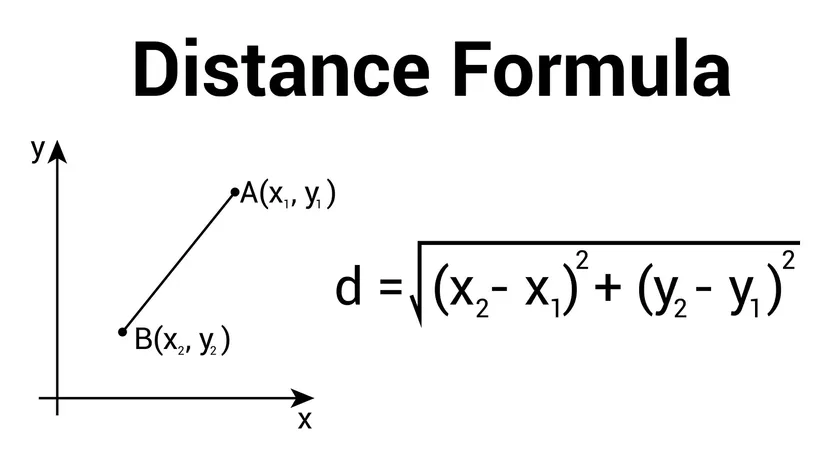


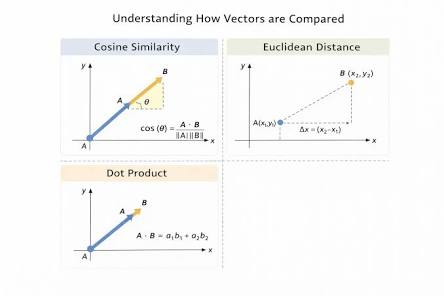

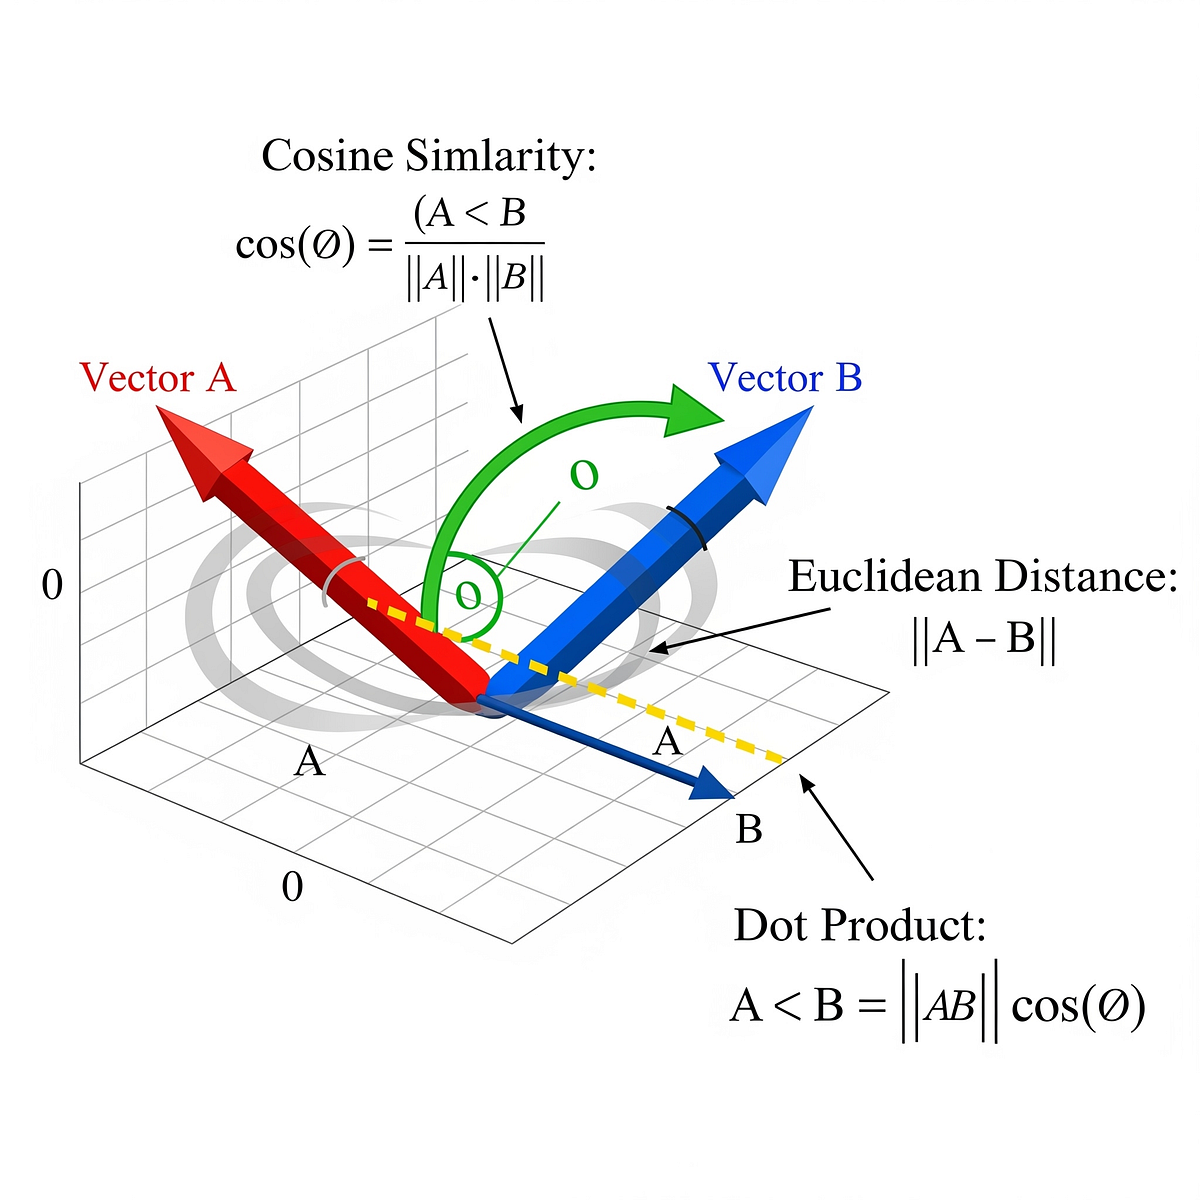

### Applying the Nearest-Neighbors Model for Retrieval

Now, let's query the model to find documents closest to a given person.

In [ ]:
def find_neighbors(query_name, model, tfidf_matrix, df, n_neighbors_to_return=5):
    query_idx = df[df['name'] == query_name].index[0]
    query_vec = tfidf_matrix[query_idx]

    distances, indices = model.kneighbors(query_vec)

    results = []
    # The first result will always be the query document itself (distance 0)
    # We want to return the top N other documents.
    for i in range(1, len(indices[0])):
        neighbor_idx = indices[0][i]
        distance = distances[0][i]
        neighbor_name = df.iloc[neighbor_idx]['name']
        if neighbor_name != query_name: # Ensure we don't include the query itself in the 'neighbors' list
            results.append({'reference_label': neighbor_name, 'distance': distance, 'rank': len(results) + 1})
        if len(results) == n_neighbors_to_return:
            break

    return pd.DataFrame(results)

# Who is closest to Obama?
obama_neighbors = find_neighbors('Barack Obama', knn_model, tfidf_matrix, people_df, n_neighbors_to_return=4)
print("Nearest neighbors for Barack Obama:")
display(obama_neighbors)

# Other examples
print("\nNearest neighbors for Taylor Swift:")
swift_neighbors = find_neighbors('Taylor Swift', knn_model, tfidf_matrix, people_df, n_neighbors_to_return=4)
display(swift_neighbors)

print("\nNearest neighbors for Angelina Jolie:")
jolie_neighbors = find_neighbors('Angelina Jolie', knn_model, tfidf_matrix, people_df, n_neighbors_to_return=4)
display(jolie_neighbors)

print("\nNearest neighbors for Arnold Schwarzenegger:")
arnold_neighbors = find_neighbors('Arnold Schwarzenegger', knn_model, tfidf_matrix, people_df, n_neighbors_to_return=4)
display(arnold_neighbors)

Nearest neighbors for Barack Obama:


,reference_label,distance,rank
0,Bill Clinton,0.636920,1
1,Arnold Schwarzenegger,0.871884,2
2,Taylor Swift,0.930579,3
3,David Beckham,0.936684,4



Nearest neighbors for Taylor Swift:


,reference_label,distance,rank
0,Angelina Jolie,0.927118,1
1,Barack Obama,0.930579,2
2,George Clooney,0.933255,3
3,Alfred J. Lewy,0.938502,4



Nearest neighbors for Angelina Jolie:


,reference_label,distance,rank
0,Taylor Swift,0.927118,1
1,Barack Obama,0.946427,2
2,George Clooney,0.948493,3
3,Alfred J. Lewy,0.952541,4



Nearest neighbors for Arnold Schwarzenegger:


,reference_label,distance,rank
0,Barack Obama,0.871884,1
1,David Beckham,0.889623,2
2,Bill Clinton,0.908919,3
3,George Clooney,0.913533,4


In this context, 'close' refers to the **textual similarity** between Wikipedia articles of Barack Obama and Bill Clinton, as calculated by the TF-IDF vectorization and cosine distance

## Most Common Shared Words for All Pairs of Individuals

Now, let's generalize the shared word analysis to all unique pairs of individuals present in our `people_df`.

In [ ]:
import itertools
import pandas as pd
from collections import Counter

# Get all unique names from the DataFrame
names = people_df['name'].unique()

# Iterate through all unique pairs of names
for name1, name2 in itertools.combinations(names, 2):
    print(f"\n--- Top 10 Shared Words between {name1} and {name2} ---")

    # Get processed text for each person in the pair
    text1 = people_df[people_df['name'] == name1]['processed_text'].iloc[0]
    text2 = people_df[people_df['name'] == name2]['processed_text'].iloc[0]

    # Get word counts for each
    word_counts1 = Counter(text1.split())
    word_counts2 = Counter(text2.split())

    # Find common words
    common_words = set(word_counts1.keys()).intersection(set(word_counts2.keys()))

    # Calculate combined frequency for common words
    shared_word_frequencies = []
    for word in common_words:
        combined_count = word_counts1[word] + word_counts2[word]
        shared_word_frequencies.append({'word': word, 'combined_count': combined_count})

    # Create a DataFrame and sort by combined count
    shared_words_pair_df = pd.DataFrame(shared_word_frequencies)
    if not shared_words_pair_df.empty:
        shared_words_pair_df = shared_words_pair_df.sort_values(by='combined_count', ascending=False).reset_index(drop=True)

        # Display the top N shared words as a table
        n_top_words = 10  # Display top 10 shared words
        if len(shared_words_pair_df) > 0:
            display(shared_words_pair_df.head(n_top_words))
        else:
            print(f"No common words found between {name1} and {name2}.")
    else:
        print(f"No common words found between {name1} and {name2}.")


--- Top 10 Shared Words between Digby Morrell and Alfred J. Lewy ---


,word,combined_count
0,born,2



--- Top 10 Shared Words between Digby Morrell and Barack Obama ---


,word,combined_count
0,born,2



--- Top 10 Shared Words between Digby Morrell and George Clooney ---


...

,word,combined_count
0,american,2
1,born,2



--- Top 10 Shared Words between Taylor Swift and Arnold Schwarzenegger ---


,word,combined_count
0,born,2



--- Top 10 Shared Words between Angelina Jolie and Arnold Schwarzenegger ---


,word,combined_count
0,born,2
